In [1]:
import wids
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

YFCC_URL = "https://storage.cmusatyalab.org/yfcc100m/yfcc100m.json"

ds = wids.ShardListDataset(YFCC_URL)

https://storage.cmusatyalab.org/yfcc100m/yfcc100m. base: https://storage.cmusatyalab.org/yfcc100m name: yfcc100m nfiles: 403 nbytes: 1264357191680 samples: 10016544 cache: /tmp/_wids_cache
/home/ubuntu/yfcc-scope/.venv/lib/python3.10/site-packages/wids/wids.py:316: UserWarning: String specifications for transformations are deprecated. Use functions instead.
  warnings.warn("String specifications for transformations are deprecated. Use functions instead.")


### Load DINOv3 Model

In [2]:
import torch

REPO_DIR = "/home/ubuntu/dinov3"
model = torch.hub.load(REPO_DIR, 'dinov3_vits16plus', source='local', weights=f"{REPO_DIR}/checkpoints/dinov3_vits16plus_pretrain_lvd1689m.pth")
model.eval()

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): SwiGLUFFN(
        (w1): Linear(in_features=384, out_features=1536, bias=True)
        (w2): Linear(in_features=384, out_features=1536, bias=True)
        (w3): Linear(in_features=1536, out_features=384, bias=True)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerNorm((384,), ep

In [3]:
from torchvision.transforms import v2

def make_transform(resize_size: int = 256):
    to_tensor = v2.ToImage()
    resize = v2.Resize((resize_size, resize_size), antialias=True)
    to_float = v2.ToDtype(torch.float32, scale=True)
    normalize = v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )
    return v2.Compose([to_tensor, resize, to_float, normalize])

### Test with the first image

In [4]:
ds[0]

{'.jpg': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375>,
 '.json': {'image_id': 10201275523,
  'user_uid': '55289779@N00',
  'flickr_url': 'http://www.flickr.com/photos/55289779@N00/10201275523/',
  'username': 'booledozer',
  'image_crc': '3e6ea67c7f',
  'upload_time': '2013-10-11T04:10:28Z',
  'license_id': 'CC-BY-SA-2.0',
  'capture_time': '2013-10-09T15:30:13',
  'camera_model': 'Panasonic DMC-ZS10',
  'caption': 'Images from the intersection of Parliament and Queen, 2013 10 09 (3)',
  'description': None,
  'tags': [],
  'machine_tags': [],
  'gps_coord': [43.649708, -79.365637]},
 '.txt': '# Images from the intersection of Parliament and Queen, 2013 10 09 (3)',
 '__key__': '10201275523',
 '__dataset__': None,
 '__index__': 0,
 '__shard__': 'https://storage.cmusatyalab.org/yfcc100m/yfcc100m-000000.tar',
 '__shardindex__': 0}

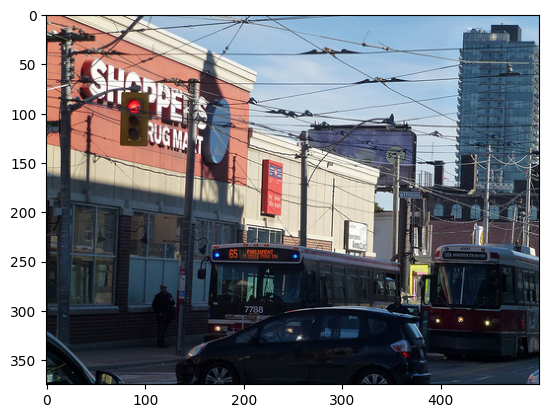

In [5]:
import matplotlib.pyplot as plt

img = ds[0][".jpg"]
plt.imshow(img)

In [ ]:
transform = make_transform()
x = transform(ds[0][".jpg"]).unsqueeze(0)

with torch.no_grad():
	emb = model(x)
	emb = emb / emb.norm(dim=-1, keepdim=True)

emb.dtype, emb.shape

torch.Size([1, 384])